# Build LogD GAT model.

This notebook shows how to build an attention-based model (GATv2Conv) to train, predict and evaluate LogD from Chembl data. 

In [1]:
import pandas as pd
import torch

import pathlib
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Setup.

In [2]:
readout = 'LogD7.4'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [4]:
# Load chembl data

df = pd.read_csv(f'{DATA}/{readout}_chembl.csv',index_col=None)
df.head(5)

,Unnamed: 0,activity_id,assay_chembl_id,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,assay_description,assay_type,smiles
0,0,32354,CHEMBL638472,CHEMBL432162,LogD,NaN,=,0.49,CHEMBL2362975,Partition coefficient (logD) (octanol/0.01 N K...,P,Cc1nc(C)c2c(n1)N(Cc1ccc(-c3ccccc3-c3nnn[nH]3)c...
1,2,33086,CHEMBL636433,CHEMBL281460,LogD,NaN,=,1.95,CHEMBL2362975,Distribution coefficient between 1-Octanol and...,P,CCC1NC(=O)OC12CCN(CCc1c[nH]c3ccccc13)CC2
2,6,34423,CHEMBL877622,CHEMBL28059,LogD,NaN,=,2.61,CHEMBL2362975,Distribution coefficient between 1-Octanol and...,P,O=C1NC(c2ccccc2)C2(CCN(CCc3c[nH]c4ccccc34)CC2)O1
3,10,35575,CHEMBL636433,CHEMBL25591,LogD,NaN,=,1.45,CHEMBL2362975,Distribution coefficient between 1-Octanol and...,P,O=C1NCC2(CCN(CCc3c[nH]c4ccccc34)CC2)O1
4,11,35649,CHEMBL877622,CHEMBL27929,LogD,NaN,=,2.42,CHEMBL2362975,Distribution coefficient between 1-Octanol and...,P,CCCC1CN(CCc2c[nH]c3ccccc23)CCC12CNC(=O)O2


  0%|          | 0/7713 [00:00<?, ?it/s]

100%|██████████| 7713/7713 [01:09<00:00, 111.01it/s]
/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1746: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


Checking X_train:
NaNs: False
Infs: False
Max value: 1000.0

Checking y_train:
NaNs: False
Infs: False
Max value: 6.9

Cleaned shape: (6170, 207)
NaNs left? False


 97%|=================== | 5975/6170 [00:23<00:00]       

Top 30 descriptors by SHAP importance:
  - MolLogP
  - fr_COO
  - fr_COO2
  - SlogP_VSA10
  - PEOE_VSA6
  - TPSA
  - BertzCT
  - PEOE_VSA4
  - PEOE_VSA2
  - AvgIpc
  - VSA_EState5
  - qed
  - PEOE_VSA1
  - PEOE_VSA8
  - SMR_VSA6
  - VSA_EState9
  - EState_VSA8
  - VSA_EState7
  - MaxPartialCharge
  - MinPartialCharge
  - fr_Ndealkylation2
  - BCUT2D_LOGPLOW
  - NHOHCount
  - BCUT2D_MRLOW
  - VSA_EState10
  - PEOE_VSA12
  - MinEStateIndex
  - fr_methoxy
  - EState_VSA10
  - MolWt


 97%|=================== | 6011/6170 [00:23<00:00]       

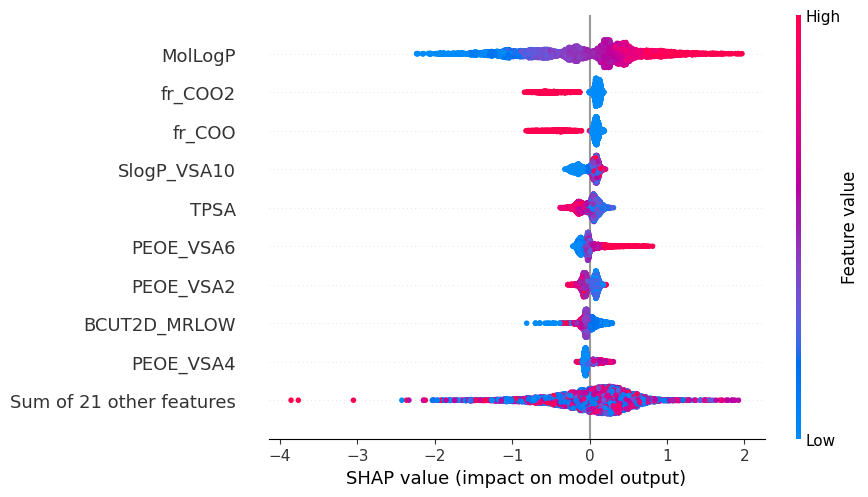


Final model with SHAP-selected features:
RMSE: 0.7913
MAE: 0.5851
R²: 0.7246


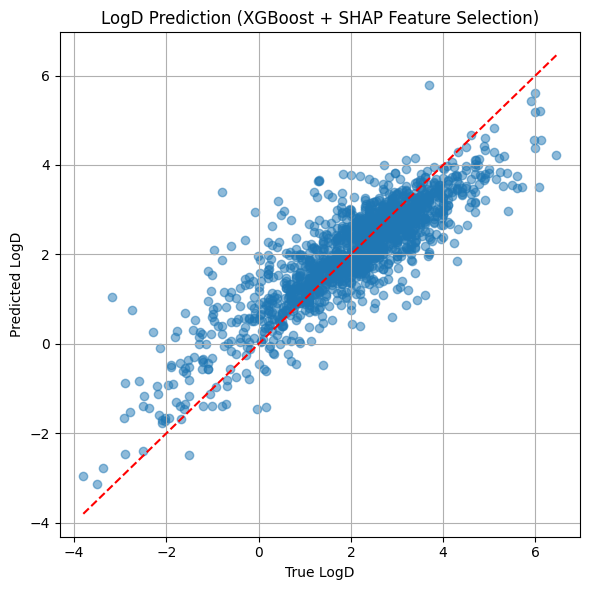

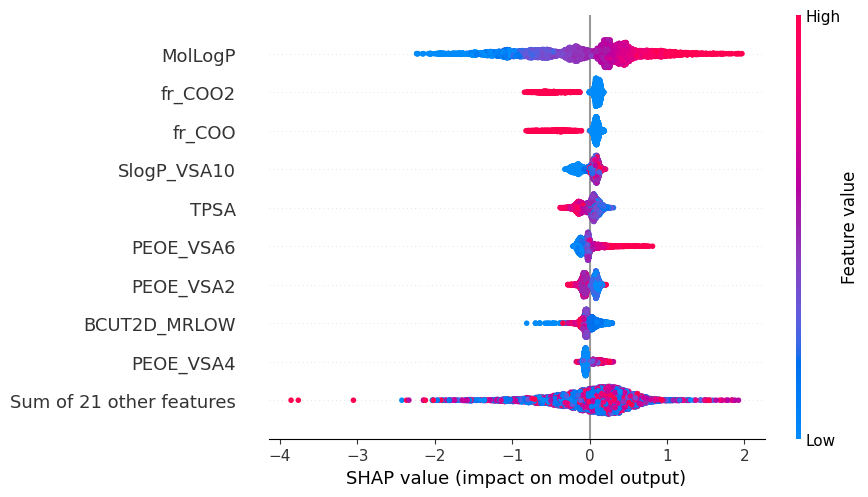

In [8]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import VarianceThreshold
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from tqdm import tqdm

# === Load data ===
smiles_list = df['smiles'].tolist()
logd_values = df['standard_value'].tolist()

# === Get all RDKit descriptor functions ===
descriptor_names, descriptor_functions = zip(*Descriptors.descList)

def compute_all_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [0.0] * len(descriptor_functions)
    values = []
    for func in descriptor_functions:
        try:
            val = func(mol)
            if np.isnan(val) or np.isinf(val):
                val = 0.0
        except:
            val = 0.0
        values.append(val)
    return values

# === Compute descriptors ===
X = np.array([compute_all_descriptors(smi) for smi in tqdm(smiles_list)])
y = np.array(logd_values)

# === Remove zero-variance features ===
selector = VarianceThreshold(threshold=0.0)
X = selector.fit_transform(X)
selected_descriptor_names = np.array(descriptor_names)[selector.get_support()]

# === Train/val split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# === Convert to DataFrames for cleaning ===
X_train_df = pd.DataFrame(X_train, columns=selected_descriptor_names)
X_val_df = pd.DataFrame(X_val, columns=selected_descriptor_names)
y_train_series = pd.Series(y_train)
y_val_series = pd.Series(y_val)

# Replace inf/-inf with NaN
X_train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
X_val_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaNs and align y accordingly
train_valid_idx = X_train_df.dropna().index
val_valid_idx = X_val_df.dropna().index

X_train_df = X_train_df.loc[train_valid_idx]
y_train_series = y_train_series.loc[train_valid_idx]

X_val_df = X_val_df.loc[val_valid_idx]
y_val_series = y_val_series.loc[val_valid_idx]

# === Add outlier handling here ===
# For example, clip extreme values in X_train_df and X_val_df
clip_lower, clip_upper = -1e3, 1e3  # adjust limits as needed
X_train_df = X_train_df.clip(lower=clip_lower, upper=clip_upper)
X_val_df = X_val_df.clip(lower=clip_lower, upper=clip_upper) 

# Convert back to numpy arrays
X_train = X_train_df.to_numpy()
y_train = y_train_series.to_numpy()
X_val = X_val_df.to_numpy()
y_val = y_val_series.to_numpy()

# === Initial XGBoost model ===
initial_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=5,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# 1. Check for NaNs, infs, or very large values in features
print("Checking X_train:")
print("NaNs:", np.isnan(X_train).any().any())
print("Infs:", np.isinf(X_train).any().any())
print("Max value:", np.max(np.abs(X_train)))

# 2. Check for the same in target
print("\nChecking y_train:")
print("NaNs:", np.isnan(y_train).any())
print("Infs:", np.isinf(y_train).any())
print("Max value:", np.max(np.abs(y_train)))

# 3. Optional: drop any rows in X_train / y_train with such values
X_train_clean = X_train.copy()
y_train_clean = y_train.copy()

X_train_clean[np.isinf(X_train_clean)] = np.nan
y_train_clean[np.isinf(y_train_clean)] = np.nan

# Create mask for rows without any NaN values in X or y
mask = ~np.isnan(X_train_clean).any(axis=1) & ~np.isnan(y_train_clean)

X_train_clean = X_train_clean[mask]
y_train_clean = y_train_clean[mask]

# 4. Confirm cleaned data
print("\nCleaned shape:", X_train_clean.shape)
print("NaNs left?", np.isnan(X_train_clean).any() or np.isnan(y_train_clean).any())


initial_model.fit(X_train, y_train)

# === SHAP analysis ===
explainer = shap.Explainer(initial_model, X_train)
shap_values = explainer(X_train)

# === Mean absolute SHAP value for each feature ===
shap_importance = np.abs(shap_values.values).mean(axis=0)
shap_ranking = np.argsort(shap_importance)[::-1]
ranked_feature_names = selected_descriptor_names[shap_ranking]

# === Select top K most important features ===
TOP_K = 30  # You can adjust this
top_indices = shap_ranking[:TOP_K]
X_train_selected = X_train[:, top_indices]
X_val_selected = X_val[:, top_indices]
selected_feature_names = selected_descriptor_names[top_indices]

print(f"Top {TOP_K} descriptors by SHAP importance:")
for name in selected_feature_names:
    print(f"  - {name}")

# === Retrain XGBoost on selected features ===
final_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=5,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
final_model.fit(X_train_selected, y_train)

# SHAP analysis with named DataFrame
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_feature_names)
explainer = shap.Explainer(final_model, X_train_selected_df)
shap_values = explainer(X_train_selected_df)
shap.plots.beeswarm(shap_values)

# === Evaluate ===
y_pred = final_model.predict(X_val_selected)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"\nFinal model with SHAP-selected features:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# === Plot true vs predicted ===
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], 'r--')
plt.xlabel("True LogD")
plt.ylabel("Predicted LogD")
plt.title("LogD Prediction (XGBoost + SHAP Feature Selection)")
plt.grid(True)
plt.tight_layout()
plt.show()

# === SHAP summary plot ===
shap.plots.beeswarm(shap_values)

In [10]:
final_model.save_model("logd_xgb.json")

# Save selected feature names
import pickle
with open("selected_features.pkl", "wb") as f:
    pickle.dump(selected_feature_names.tolist(), f)